<a href="https://colab.research.google.com/github/ayu69hub/Pyton-basic--adv/blob/main/IPL_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
from google.colab import files

uploaded = files.upload()

Saving deliveries.csv.zip to deliveries.csv.zip


In [4]:
import zipfile

with zipfile.ZipFile("deliveries.csv.zip", 'r') as zip_ref:
    zip_ref.extractall("ipl_data")

In [5]:
import os

os.listdir("ipl_data")

['deliveries.csv']

In [6]:
import pandas as pd

df = pd.read_csv("ipl_data/deliveries.csv")

In [7]:
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [12]:
df.shape

(260920, 17)

In [13]:
df.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [15]:
df.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [8]:
df.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


In [9]:
df['total_runs'].sum()

np.int64(347756)

In [10]:
df['is_wicket'].sum()

np.int64(12950)

In [11]:
top_batsmen = df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

print(top_batsmen)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


In [16]:
top_bowlers = df.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

print(top_bowlers)

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64


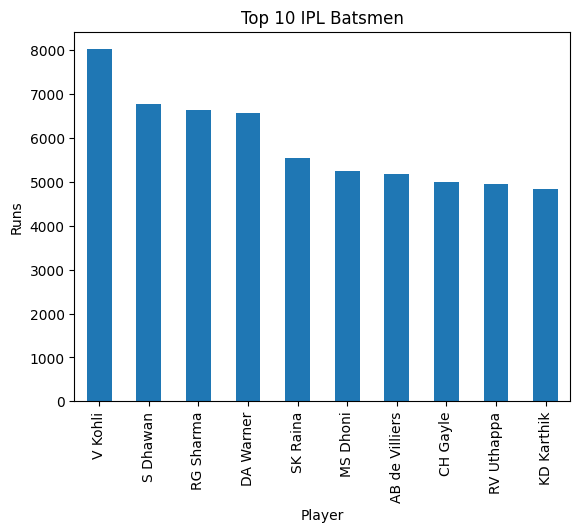

In [17]:
top_batsmen.plot(kind='bar')

plt.title("Top 10 IPL Batsmen")
plt.xlabel("Player")
plt.ylabel("Runs")

plt.show()

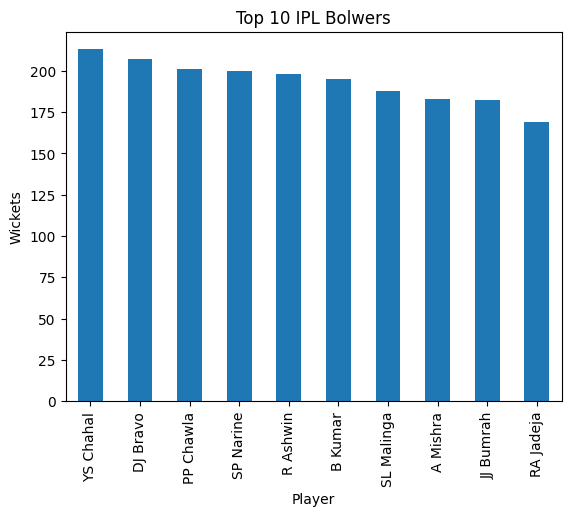

In [19]:
top_bowlers.plot(kind='bar')

plt.title("Top 10 IPL Bolwers")
plt.xlabel("Player")
plt.ylabel("Wickets")

plt.show()

**Strike rate**

In [22]:
balls = df.groupby('batter')['ball'].count()

In [23]:
runs = df.groupby('batter')['batsman_runs'].sum()

In [24]:
sr = pd.DataFrame({
    'Runs': runs,
    'Balls': balls
})

In [25]:
sr['Strike Rate'] = (sr['Runs'] / sr['Balls']) * 100

In [26]:
sr.head()

,Runs,Balls,Strike Rate
batter,,,
A Ashish Reddy,280,196,142.857143
A Badoni,634,505,125.544554
A Chandila,4,7,57.142857
A Chopra,53,75,70.666667
A Choudhary,25,20,125.000000


In [28]:
sr = sr[sr['Balls'] >= 500]

In [29]:
sr.sort_values(by='Strike Rate', ascending=False).head(10)

,Runs,Balls,Strike Rate
batter,,,
AD Russell,2488,1515,164.224422
H Klaasen,993,613,161.990212
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
LS Livingstone,939,609,154.187192
GJ Maxwell,2772,1842,150.488599
RM Patidar,799,534,149.625468
Abhishek Sharma,1377,925,148.864865
V Sehwag,2728,1833,148.827059


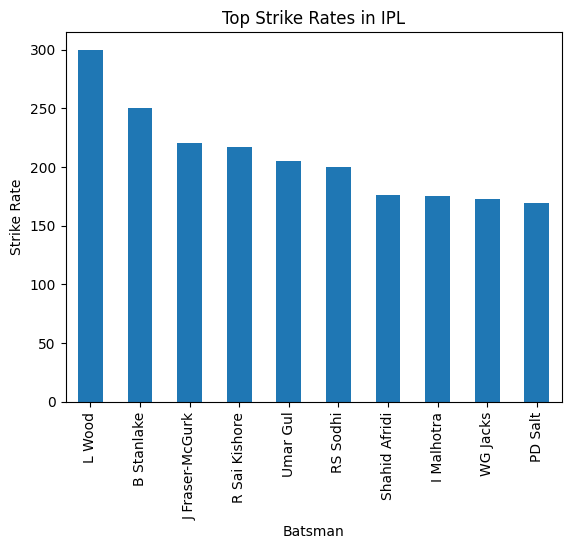

In [27]:
top_sr = sr.sort_values(by='Strike Rate', ascending=False).head(10)

top_sr['Strike Rate'].plot(kind='bar')

plt.title("Top Strike Rates in IPL")
plt.xlabel("Batsman")
plt.ylabel("Strike Rate")

plt.show()

*Most Sixes*

In [30]:
sixes = df[df['batsman_runs'] == 6]

top_sixes = sixes.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)

top_sixes

,batsman_runs
batter,
CH Gayle,359
RG Sharma,281
V Kohli,273
AB de Villiers,253
MS Dhoni,252
DA Warner,236
KA Pollard,224
AD Russell,209
SV Samson,206


*Most fours*

In [31]:
fours = df[df['batsman_runs'] == 4]

top_fours = fours.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)

top_fours

,batsman_runs
batter,
S Dhawan,768
V Kohli,708
DA Warner,663
RG Sharma,599
SK Raina,506
G Gambhir,492
RV Uthappa,481
AM Rahane,479
KD Karthik,466


*Total run scored by a team*

In [32]:
team_runs = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)

team_runs

,total_runs
batting_team,
Mumbai Indians,42176
Kolkata Knight Riders,39331
Chennai Super Kings,38629
Royal Challengers Bangalore,37692
Rajasthan Royals,34747
Kings XI Punjab,30064
Sunrisers Hyderabad,29071
Delhi Daredevils,24296
Delhi Capitals,14900
